<a href="https://colab.research.google.com/github/gagandeep02/Data-Visualisation/blob/main/My_work28_06_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

========== DATA LOADED ==========
Records used: 8469
Ticket types: ['Billing inquiry', 'Cancellation request', 'Product inquiry', 'Refund request', 'Technical issue']

========== DYNAMIC WORKFLOW POLICY CREATED ==========
Ticket workflows: 5
Priority rules: 4


config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

...

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]


========== LLM LOADED ==========
LLM model: google/flan-t5-small
Device: cpu

========== EVALUATING LLM AGENT ==========
Allowed ticket types: ['Billing inquiry', 'Cancellation request', 'Product inquiry', 'Refund request', 'Technical issue']
Evaluation records: 50
Processed 10/50 tickets
Processed 20/50 tickets
Processed 30/50 tickets
Processed 40/50 tickets
Processed 50/50 tickets

========== LLM AGENT PERFORMANCE ==========
Dataset used: Customer Support Ticket Dataset
LLM model: google/flan-t5-small
Total records used: 8469
Evaluated records: 50
Accuracy: 0.18
Task success rate: 0.18
Failure rate: 0.82
Average reliability score: 0.222
Average latency per ticket: 0.7522 seconds

========== FAILURE MODES ==========
failure_mode
wrong_class_high_confidence    35
success                         9
wrong_class_low_confidence      6
Name: count, dtype: int64

========== HUMAN TRUST ESTIMATE ==========
human_trust_estimate
low_trust     41
high_trust     9
Name: count, dtype: int64

=====

AI Agent Failure Modes

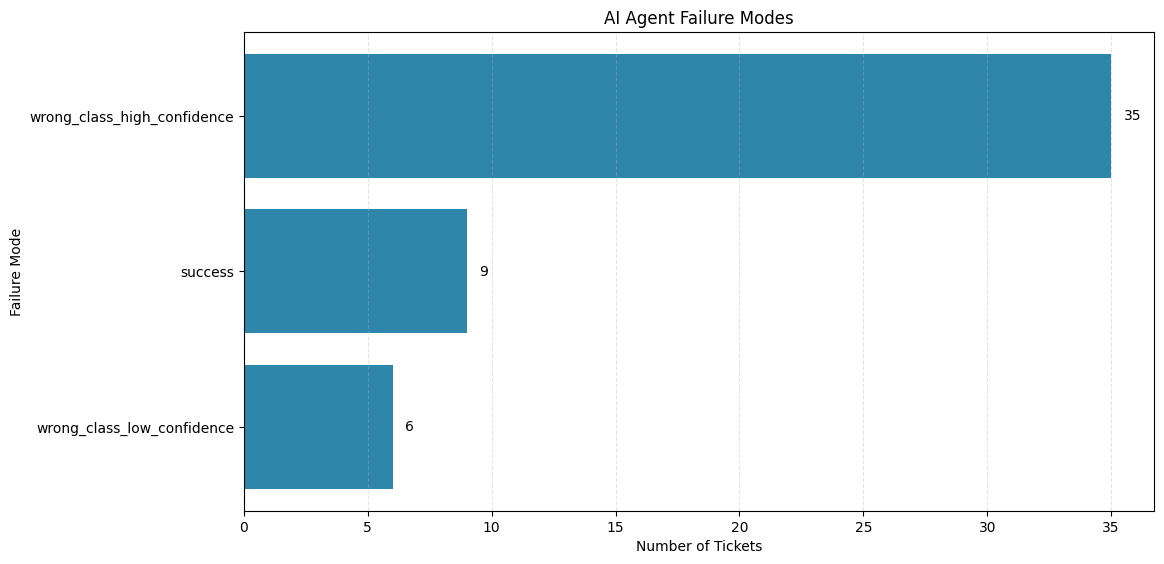

Estimated Human Trust Distribution

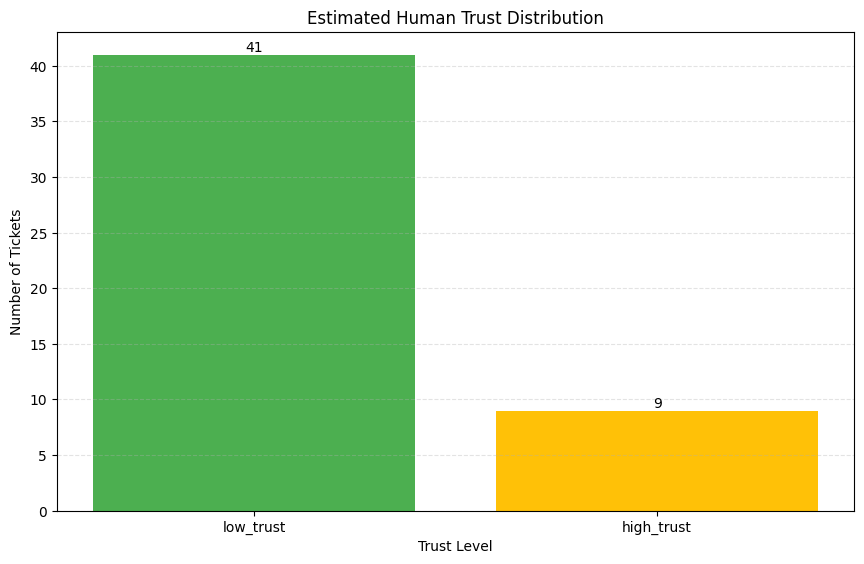

Reliability Score Distribution

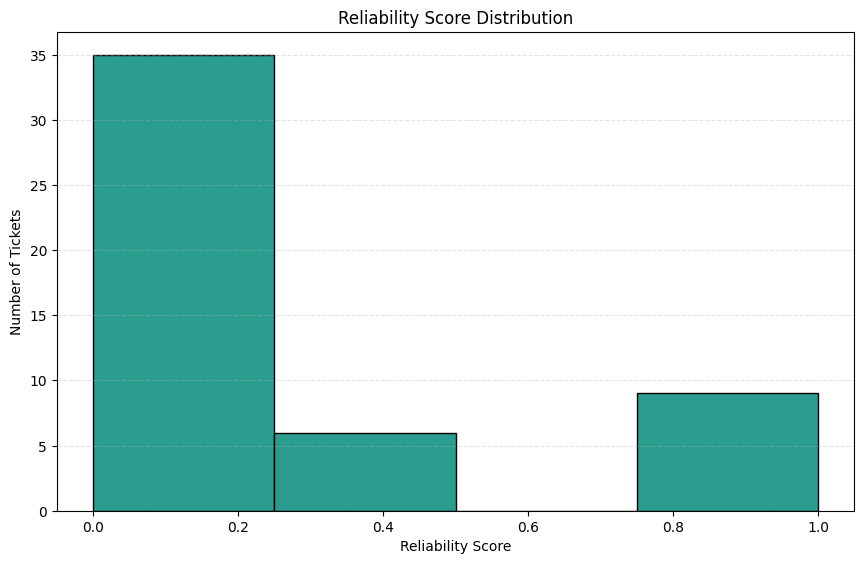

Ticket Type Confusion Matrix

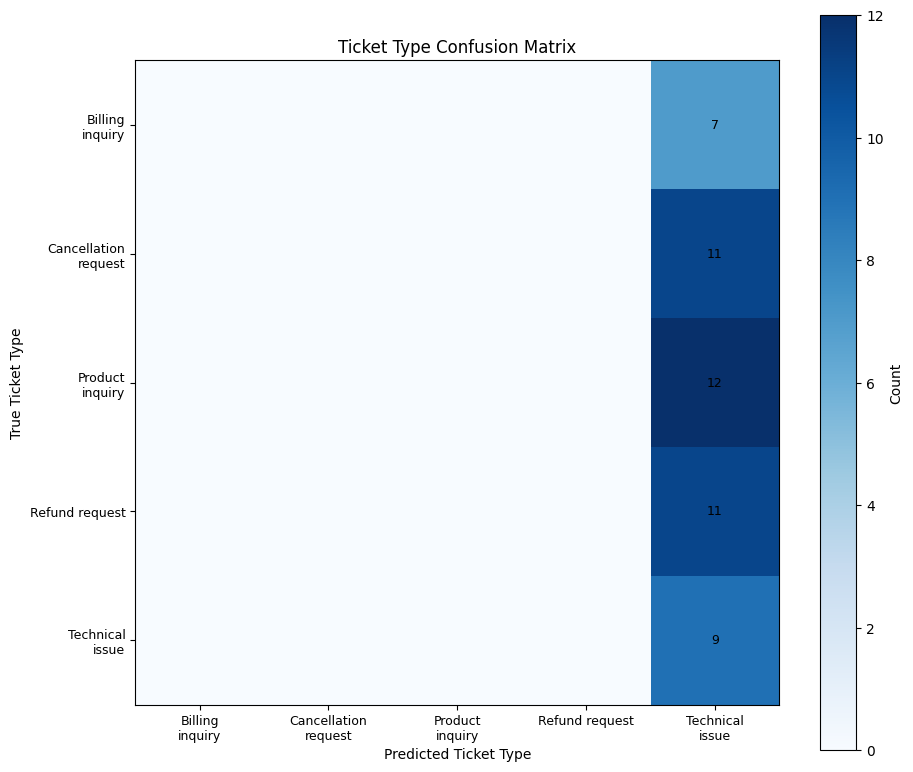





========== FILES SAVED ==========
llm_agent_reliability_evaluation_results.csv
llm_ticket_type_confusion_matrix.csv
llm_agent_reliability_summary.json
llm_failure_recovery_recommendations.txt
simulated_human_trust_survey.csv
dynamic_workflow_policy.json
failure_modes_graph.png
trust_distribution_graph.png
reliability_score_graph.png
confusion_matrix_graph.png

========== NEW TICKET PREDICTION ==========
Subject: Payment failed but money deducted
Description: Customer paid during checkout, amount was deducted, but order was not confirmed.
Priority: High
Raw LLM output: Customer support
Predicted ticket type: Technical issue
Confidence: 0.3
Business action: Human review required before automation; Escalate to senior support team; route to technical_issue_workflow; owner team: Technical issue Support Team; SLA: Immediate review required
Error recovery action: Ask one clarifying question, then route after confirmation.
LLM-generated response: Customer service is not available.

=======

In [1]:

import json
import time
import difflib
import textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer



DATASET_PATH = "customer_support_tickets.csv"

LLM_MODEL_NAME = "google/flan-t5-small"

RANDOM_STATE = 42
TEST_SIZE = 0.25

EVALUATION_SAMPLE_SIZE = 50

CONFIDENCE_THRESHOLD = 0.60
SIMULATED_PARTICIPANTS = 30

WORKFLOW_POLICY = {}



def normalize_columns(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )
    return df


def find_column(df, possible_names):
    for name in possible_names:
        if name in df.columns:
            return name
    raise ValueError(
        "Required column not found. Tried: "
        + ", ".join(possible_names)
        + "\nAvailable columns: "
        + ", ".join(df.columns)
    )


def load_and_prepare_data(path):
    path = Path(path)

    if not path.exists():
        csv_files = sorted(Path.cwd().glob("*.csv"))
        if len(csv_files) == 1:
            path = csv_files[0]
            print("Using detected CSV file:", path)
        else:
            raise FileNotFoundError(
                f"Dataset file not found: {path}\n"
                "Upload customer_support_tickets.csv in Colab, or update DATASET_PATH.\n"
                "CSV files found: " + ", ".join(str(file) for file in csv_files)
            )

    df = pd.read_csv(path)
    df = normalize_columns(df)

    subject_col = find_column(df, [
        "ticket_subject",
        "subject",
        "title",
        "issue_subject",
    ])

    description_col = find_column(df, [
        "ticket_description",
        "description",
        "issue_description",
        "text",
        "query",
        "message",
    ])

    type_col = find_column(df, [
        "ticket_type",
        "type",
        "category",
        "intent",
        "issue_type",
    ])

    priority_col = find_column(df, [
        "ticket_priority",
        "priority",
        "urgency",
    ])

    optional_cols = []
    for col in [
        "ticket_status",
        "status",
        "customer_satisfaction_rating",
        "satisfaction_rating",
    ]:
        if col in df.columns:
            optional_cols.append(col)

    df["input_text"] = (
        df[subject_col].fillna("").astype(str)
        + " "
        + df[description_col].fillna("").astype(str)
    )

    data = df[["input_text", type_col, priority_col] + optional_cols].copy()

    rename_map = {
        type_col: "ticket_type",
        priority_col: "ticket_priority",
        "status": "ticket_status",
        "satisfaction_rating": "customer_satisfaction_rating",
    }

    data = data.rename(columns={k: v for k, v in rename_map.items() if k in data.columns})

    data["input_text"] = data["input_text"].fillna("").astype(str)
    data["ticket_type"] = data["ticket_type"].fillna("").astype(str)
    data["ticket_priority"] = data["ticket_priority"].fillna("").astype(str)

    data = data[data["input_text"].str.strip().str.len() > 5]
    data = data[data["ticket_type"].str.strip().str.len() > 0]

    class_counts = data["ticket_type"].value_counts()
    valid_classes = class_counts[class_counts >= 2].index
    data = data[data["ticket_type"].isin(valid_classes)].reset_index(drop=True)

    print("========== DATA LOADED ==========")
    print("Records used:", len(data))
    print("Ticket types:", sorted(data["ticket_type"].unique()))

    return data


def build_dynamic_workflow_policy(data):
    ticket_types = sorted(data["ticket_type"].unique())
    priorities = sorted(data["ticket_priority"].unique())

    policy = {
        "ticket_types": ticket_types,
        "priorities": priorities,
        "confidence_threshold": CONFIDENCE_THRESHOLD,
        "routing_rules": {},
        "priority_rules": {},
    }

    for ticket_type in ticket_types:
        route_name = (
            str(ticket_type)
            .strip()
            .lower()
            .replace(" ", "_")
            .replace("/", "_")
            .replace("-", "_")
        )

        policy["routing_rules"][ticket_type] = {
            "workflow_name": f"{route_name}_workflow",
            "owner_team": f"{ticket_type} Support Team",
            "requires_audit_log": True,
        }

    for priority in priorities:
        priority_text = str(priority).lower()

        if any(word in priority_text for word in ["critical", "urgent", "high"]):
            priority_level = "high"
            sla = "Immediate review required"
            escalation = "Escalate to senior support team"
        elif any(word in priority_text for word in ["medium", "normal"]):
            priority_level = "medium"
            sla = "Standard business queue"
            escalation = "Assign to standard support queue"
        else:
            priority_level = "low"
            sla = "Normal support queue"
            escalation = "Assign to normal support queue"

        policy["priority_rules"][priority] = {
            "priority_level": priority_level,
            "sla": sla,
            "escalation_action": escalation,
        }

    print("\n========== DYNAMIC WORKFLOW POLICY CREATED ==========")
    print("Ticket workflows:", len(policy["routing_rules"]))
    print("Priority rules:", len(policy["priority_rules"]))

    with open("dynamic_workflow_policy.json", "w", encoding="utf-8") as file:
        json.dump(policy, file, indent=4)

    return policy




def load_llm():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL_NAME)
    model = AutoModelForSeq2SeqLM.from_pretrained(LLM_MODEL_NAME).to(device)
    model.eval()

    print("\n========== LLM LOADED ==========")
    print("LLM model:", LLM_MODEL_NAME)
    print("Device:", device)

    return {
        "tokenizer": tokenizer,
        "model": model,
        "device": device,
    }


def generate_text(llm, prompt, max_new_tokens=40):
    tokenizer = llm["tokenizer"]
    model = llm["model"]
    device = llm["device"]

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512,
    ).to(device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )

    return tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()




def make_classification_prompt(ticket_text, priority, labels):
    label_text = ", ".join(labels)

    return f"""
You are an LLM-powered AI agent for business process automation.
Your task is to classify a customer support ticket into exactly one ticket type.

Allowed ticket types:
{label_text}

Ticket priority: {priority}
Ticket text: {ticket_text}

Return only one ticket type from the allowed list.
"""


def normalize_prediction(raw_prediction, labels):
    raw = str(raw_prediction).strip()
    raw_lower = raw.lower()

    for label in labels:
        if raw_lower == label.lower():
            return label

    for label in labels:
        if label.lower() in raw_lower or raw_lower in label.lower():
            return label

    close = difflib.get_close_matches(raw, labels, n=1, cutoff=0.0)
    return close[0] if close else labels[0]


def pseudo_confidence(raw_prediction, selected_label):
    raw = str(raw_prediction).strip().lower()
    label = str(selected_label).strip().lower()

    if raw == label:
        return 0.95

    if label in raw or raw in label:
        return 0.80

    similarity = difflib.SequenceMatcher(None, raw, label).ratio()
    return round(max(0.30, min(0.75, similarity)), 4)


def llm_classify_ticket(llm, ticket_text, priority, labels):
    prompt = make_classification_prompt(ticket_text, priority, labels)
    raw_output = generate_text(llm, prompt, max_new_tokens=20)
    predicted_type = normalize_prediction(raw_output, labels)
    confidence = pseudo_confidence(raw_output, predicted_type)

    return predicted_type, confidence, raw_output


def business_action(predicted_type, priority, confidence, workflow_policy):
    routing_rule = workflow_policy["routing_rules"].get(predicted_type, {
        "workflow_name": "general_support_workflow",
        "owner_team": "General Support Team",
        "requires_audit_log": True,
    })

    priority_rule = workflow_policy["priority_rules"].get(priority, {
        "priority_level": "unknown",
        "sla": "Manual SLA review required",
        "escalation_action": "Send to support coordinator",
    })

    if confidence < workflow_policy["confidence_threshold"]:
        review_action = "Human review required before automation"
    else:
        review_action = "Automation allowed"

    return (
        f"{review_action}; "
        f"{priority_rule['escalation_action']}; "
        f"route to {routing_rule['workflow_name']}; "
        f"owner team: {routing_rule['owner_team']}; "
        f"SLA: {priority_rule['sla']}"
    )


def failure_mode(true_type, predicted_type, confidence):
    if true_type == predicted_type and confidence >= CONFIDENCE_THRESHOLD:
        return "success"

    if true_type == predicted_type and confidence < CONFIDENCE_THRESHOLD:
        return "low_confidence_success"

    if true_type != predicted_type and confidence >= CONFIDENCE_THRESHOLD:
        return "wrong_class_high_confidence"

    return "wrong_class_low_confidence"


def error_recovery_action(mode):
    recovery = {
        "success": "Proceed with automated workflow and log the decision for audit.",
        "low_confidence_success": "Ask one clarifying question, then route after confirmation.",
        "wrong_class_low_confidence": "Stop automation, send to human review, and request missing details.",
        "wrong_class_high_confidence": "Critical failure: block automation, escalate to supervisor, and log for model review.",
    }

    return recovery.get(mode, "Send to human review and log unknown failure.")


def reliability_score(mode):
    scores = {
        "success": 1.00,
        "low_confidence_success": 0.75,
        "wrong_class_low_confidence": 0.35,
        "wrong_class_high_confidence": 0.00,
    }

    return scores.get(mode, 0.00)


def trust_label(score):
    if score >= 0.80:
        return "high_trust"

    if score >= 0.50:
        return "medium_trust"

    return "low_trust"


def generate_customer_response(llm, ticket_text, predicted_type, priority, recovery_action, workflow_policy):
    routing_rule = workflow_policy["routing_rules"].get(predicted_type, {
        "workflow_name": "general_support_workflow",
        "owner_team": "General Support Team",
    })

    prompt = f"""
You are an LLM-powered customer support agent.
Write a short professional customer-support response.

Ticket type: {predicted_type}
Priority: {priority}
Ticket text: {ticket_text}
Assigned team: {routing_rule['owner_team']}
Internal action: {recovery_action}

Response:
"""

    return generate_text(llm, prompt, max_new_tokens=80)


def simulate_human_trust_survey(average_reliability):
    np.random.seed(RANDOM_STATE)
    rows = []

    for participant_id in range(1, SIMULATED_PARTICIPANTS + 1):
        pre_trust = np.random.randint(3, 6)

        if average_reliability >= 0.80:
            change = np.random.choice([1, 2], p=[0.45, 0.55])
        elif average_reliability >= 0.50:
            change = np.random.choice([-1, 0, 1], p=[0.20, 0.45, 0.35])
        else:
            change = np.random.choice([-2, -1, 0], p=[0.35, 0.45, 0.20])

        post_trust = int(max(1, min(7, pre_trust + change)))

        rows.append({
            "participant_id": participant_id,
            "pre_interaction_trust_1_to_7": int(pre_trust),
            "post_interaction_trust_1_to_7": post_trust,
            "trust_change": post_trust - int(pre_trust),
            "perceived_reliability_condition": trust_label(average_reliability),
        })

    return pd.DataFrame(rows)



def create_visual_graphs(result_df, cm_df):
    plt.style.use("default")

    failure_counts = result_df["failure_mode"].value_counts()

    display(Markdown("AI Agent Failure Modes"))
    plt.figure(figsize=(12, 6))
    bars = plt.barh(
        failure_counts.index[::-1],
        failure_counts.values[::-1],
        color="#2E86AB",
    )
    plt.title("AI Agent Failure Modes")
    plt.xlabel("Number of Tickets")
    plt.ylabel("Failure Mode")
    plt.grid(axis="x", linestyle="--", alpha=0.35)

    for bar in bars:
        plt.text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            int(bar.get_width()),
            ha="left",
            va="center",
        )

    plt.tight_layout(pad=2.0)
    plt.savefig("failure_modes_graph.png", dpi=200)
    plt.show()
    print("\n\n")

    trust_counts = result_df["human_trust_estimate"].value_counts()

    display(Markdown("Estimated Human Trust Distribution"))
    plt.figure(figsize=(9, 6))
    bars = plt.bar(
        trust_counts.index,
        trust_counts.values,
        color=["#4CAF50", "#FFC107", "#F44336"],
    )
    plt.title("Estimated Human Trust Distribution")
    plt.xlabel("Trust Level")
    plt.ylabel("Number of Tickets")

    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            int(bar.get_height()),
            ha="center",
            va="bottom",
        )

    plt.grid(axis="y", linestyle="--", alpha=0.35)
    plt.tight_layout(pad=2.0)
    plt.savefig("trust_distribution_graph.png", dpi=200)
    plt.show()
    print("\n\n")

    display(Markdown("Reliability Score Distribution"))
    plt.figure(figsize=(9, 6))
    plt.hist(
        result_df["reliability_score"],
        bins=[0, 0.25, 0.5, 0.75, 1.0],
        color="#2A9D8F",
        edgecolor="black",
    )
    plt.title("Reliability Score Distribution")
    plt.xlabel("Reliability Score")
    plt.ylabel("Number of Tickets")
    plt.grid(axis="y", linestyle="--", alpha=0.35)
    plt.tight_layout(pad=2.0)
    plt.savefig("reliability_score_graph.png", dpi=200)
    plt.show()
    print("\n\n")

    wrapped_x_labels = ["\n".join(textwrap.wrap(str(label), width=14)) for label in cm_df.columns]
    wrapped_y_labels = ["\n".join(textwrap.wrap(str(label), width=14)) for label in cm_df.index]

    display(Markdown("Ticket Type Confusion Matrix"))
    matrix_size = max(10, len(cm_df.columns) * 1.6)
    plt.figure(figsize=(matrix_size, matrix_size * 0.85))
    plt.imshow(cm_df.values, cmap="Blues")
    plt.title("Ticket Type Confusion Matrix")
    plt.xlabel("Predicted Ticket Type")
    plt.ylabel("True Ticket Type")
    plt.xticks(range(len(cm_df.columns)), wrapped_x_labels, rotation=0, ha="center", fontsize=9)
    plt.yticks(range(len(cm_df.index)), wrapped_y_labels, fontsize=9)
    plt.colorbar(label="Count")

    for i in range(len(cm_df.index)):
        for j in range(len(cm_df.columns)):
            value = cm_df.values[i, j]
            if value > 0:
                plt.text(j, i, value, ha="center", va="center", color="black", fontsize=9)

    plt.tight_layout(pad=2.5)
    plt.savefig("confusion_matrix_graph.png", dpi=200)
    plt.show()
    print("\n\n")



def create_recommendations(summary, result_df, workflow_policy):
    lines = [
        "LLM-Powered AI Agent Failure, Reliability, and Trust Analysis",
        "",
        f"Model used: {summary['llm_model']}",
        f"Accuracy: {summary['accuracy']}",
        f"Task success rate: {summary['task_success_rate']}",
        f"Failure rate: {summary['failure_rate']}",
        f"Average reliability score: {summary['average_reliability_score']}",
        f"Dynamic workflows created: {len(workflow_policy['routing_rules'])}",
        f"Dynamic priority rules created: {len(workflow_policy['priority_rules'])}",
        "",
        "Failure mode counts:",
    ]

    for key, value in result_df["failure_mode"].value_counts().to_dict().items():
        lines.append(f"- {key}: {value}")

    lines.extend([
        "",
        "Interpretation:",
        "This system uses an instruction-tuned LLM to classify customer support tickets, dynamically recommend workflow routing, generate customer responses, and evaluate reliability.",
        "Low-confidence or wrong-class predictions should not be fully automated.",
        "",
        "Recommended improvements:",
        "1. Use a larger LLM such as google/flan-t5-base, Llama, Gemini, or GPT.",
        "2. Add few-shot examples for each ticket type.",
        "3. Add business policy documents using retrieval-augmented generation.",
        "4. Keep human-in-the-loop review for high-priority or low-confidence tickets.",
        "5. Replace simulated trust data with real participant questionnaire data if required.",
    ])

    return "\n".join(lines)




def evaluate_llm_agent(data, llm, workflow_policy):
    class_count = data["ticket_type"].nunique()
    test_size_count = int(len(data) * TEST_SIZE)
    can_stratify = class_count > 1 and test_size_count >= class_count
    stratify_target = data["ticket_type"] if can_stratify else None

    train_df, test_df = train_test_split(
        data,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=stratify_target,
    )

    if EVALUATION_SAMPLE_SIZE is not None and len(test_df) > EVALUATION_SAMPLE_SIZE:
        test_df = test_df.sample(EVALUATION_SAMPLE_SIZE, random_state=RANDOM_STATE)

    labels = sorted(train_df["ticket_type"].unique())
    results = []

    print("\n========== EVALUATING LLM AGENT ==========")
    print("Allowed ticket types:", labels)
    print("Evaluation records:", len(test_df))

    start_time = time.time()

    for index, row in test_df.reset_index(drop=True).iterrows():
        predicted_type, confidence, raw_output = llm_classify_ticket(
            llm=llm,
            ticket_text=row["input_text"],
            priority=row["ticket_priority"],
            labels=labels,
        )

        mode = failure_mode(row["ticket_type"], predicted_type, confidence)
        score = reliability_score(mode)
        recovery = error_recovery_action(mode)

        results.append({
            "input_text": row["input_text"],
            "ticket_priority": row["ticket_priority"],
            "true_ticket_type": row["ticket_type"],
            "llm_raw_output": raw_output,
            "predicted_ticket_type": predicted_type,
            "confidence": confidence,
            "business_action": business_action(
                predicted_type,
                row["ticket_priority"],
                confidence,
                workflow_policy,
            ),
            "failure_mode": mode,
            "error_recovery_action": recovery,
            "reliability_score": score,
            "human_trust_estimate": trust_label(score),
        })

        if (index + 1) % 10 == 0:
            print(f"Processed {index + 1}/{len(test_df)} tickets")

    avg_latency = (time.time() - start_time) / len(test_df)
    result_df = pd.DataFrame(results)

    accuracy = accuracy_score(result_df["true_ticket_type"], result_df["predicted_ticket_type"])
    task_success_rate = (result_df["failure_mode"] == "success").mean()
    failure_rate = 1 - task_success_rate
    average_reliability = result_df["reliability_score"].mean()

    print("\n========== LLM AGENT PERFORMANCE ==========")
    print("Dataset used: Customer Support Ticket Dataset")
    print("LLM model:", LLM_MODEL_NAME)
    print("Total records used:", len(data))
    print("Evaluated records:", len(test_df))
    print("Accuracy:", round(accuracy, 4))
    print("Task success rate:", round(task_success_rate, 4))
    print("Failure rate:", round(failure_rate, 4))
    print("Average reliability score:", round(average_reliability, 4))
    print("Average latency per ticket:", round(avg_latency, 4), "seconds")

    print("\n========== FAILURE MODES ==========")
    print(result_df["failure_mode"].value_counts())

    print("\n========== HUMAN TRUST ESTIMATE ==========")
    print(result_df["human_trust_estimate"].value_counts())

    print("\n========== CLASSIFICATION REPORT ==========")
    print(classification_report(
        result_df["true_ticket_type"],
        result_df["predicted_ticket_type"],
        zero_division=0,
    ))

    labels_all = sorted(set(result_df["true_ticket_type"]) | set(result_df["predicted_ticket_type"]))

    cm = confusion_matrix(
        result_df["true_ticket_type"],
        result_df["predicted_ticket_type"],
        labels=labels_all,
    )

    cm_df = pd.DataFrame(cm, index=labels_all, columns=labels_all)

    result_df.to_csv("llm_agent_reliability_evaluation_results.csv", index=False)
    cm_df.to_csv("llm_ticket_type_confusion_matrix.csv")

    summary = {
        "dataset": "Customer Support Ticket Dataset",
        "llm_model": LLM_MODEL_NAME,
        "records_used": int(len(data)),
        "evaluated_records": int(len(test_df)),
        "accuracy": float(round(accuracy, 4)),
        "task_success_rate": float(round(task_success_rate, 4)),
        "failure_rate": float(round(failure_rate, 4)),
        "average_reliability_score": float(round(average_reliability, 4)),
        "average_latency_seconds": float(round(avg_latency, 4)),
    }

    with open("llm_agent_reliability_summary.json", "w", encoding="utf-8") as file:
        json.dump(summary, file, indent=4)

    with open("llm_failure_recovery_recommendations.txt", "w", encoding="utf-8") as file:
        file.write(create_recommendations(summary, result_df, workflow_policy))

    survey_df = simulate_human_trust_survey(average_reliability)
    survey_df.to_csv("simulated_human_trust_survey.csv", index=False)

    create_visual_graphs(result_df, cm_df)

    print("\n========== FILES SAVED ==========")
    print("llm_agent_reliability_evaluation_results.csv")
    print("llm_ticket_type_confusion_matrix.csv")
    print("llm_agent_reliability_summary.json")
    print("llm_failure_recovery_recommendations.txt")
    print("simulated_human_trust_survey.csv")
    print("dynamic_workflow_policy.json")
    print("failure_modes_graph.png")
    print("trust_distribution_graph.png")
    print("reliability_score_graph.png")
    print("confusion_matrix_graph.png")

    return result_df




def predict_new_ticket(llm, data, subject, description, priority, workflow_policy):
    labels = sorted(data["ticket_type"].unique())
    text = subject + " " + description

    predicted_type, confidence, raw_output = llm_classify_ticket(
        llm=llm,
        ticket_text=text,
        priority=priority,
        labels=labels,
    )

    mode = "success" if confidence >= CONFIDENCE_THRESHOLD else "low_confidence_success"
    recovery = error_recovery_action(mode)
    response = generate_customer_response(
        llm,
        text,
        predicted_type,
        priority,
        recovery,
        workflow_policy,
    )

    print("\n========== NEW TICKET PREDICTION ==========")
    print("Subject:", subject)
    print("Description:", description)
    print("Priority:", priority)
    print("Raw LLM output:", raw_output)
    print("Predicted ticket type:", predicted_type)
    print("Confidence:", confidence)
    print("Business action:", business_action(predicted_type, priority, confidence, workflow_policy))
    print("Error recovery action:", recovery)
    print("LLM-generated response:", response)




data = load_and_prepare_data(DATASET_PATH)
WORKFLOW_POLICY = build_dynamic_workflow_policy(data)
llm = load_llm()
results = evaluate_llm_agent(data, llm, WORKFLOW_POLICY)

predict_new_ticket(
    llm=llm,
    data=data,
    subject="Payment failed but money deducted",
    description="Customer paid during checkout, amount was deducted, but order was not confirmed.",
    priority="High",
    workflow_policy=WORKFLOW_POLICY,
)

predict_new_ticket(
    llm=llm,
    data=data,
    subject="Product stopped working",
    description="The device stopped working after two days and customer needs replacement.",
    priority="Medium",
    workflow_policy=WORKFLOW_POLICY,
)
